# **Kidus Tesema**
# **year Up United**
# **Analysis for Len Jensen**

# Capstone 2: EmporiUm Sales Analysis for Len Jensen

This project analyzes the sales performance of the stores managed by Len Jensen. Len Jensen manages two South region stores: Store 852 in Charleston, South Carolina and Store 853 in Greenville, South Carolina.

The goal of this analysis is to compare store performance, monthly revenue, top customers, product category activity, and make a marketing recommendation for the next quarter.

Loading your libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

Loading the CSV files

In [9]:
customers = pd.read_csv("customer_list.csv", sep="|")
categories = pd.read_csv("ProductCategories.csv")
products = pd.read_csv("Products.csv")
stores = pd.read_csv("StoreDetail.csv")
sales = pd.read_csv("StoreSales.csv")

check check

In [25]:
customers.info()
categories.info()
products.info()
stores.info()
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column       

In [10]:
len_stores = stores[stores["Territory Manager"] == "Len Jensen"]
len_stores

,Store Location,State,Store ID,Territory Manager,Region,Region Director
98,Charleston,South Carolina,852,Len Jensen,South,Andy Gisselquist
99,Greenville,South Carolina,853,Len Jensen,South,Andy Gisselquist


In [12]:
len_sales = sales.merge(len_stores, on="Store ID", how="inner")
len_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,1/1/2022,853,NaN,105453-T,159.58,Greenville,South Carolina,Len Jensen,South,Andy Gisselquist
1,1/3/2022,852,NaN,105615-B,28.92,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist
2,1/3/2022,853,454.0,105424-T,192.26,Greenville,South Carolina,Len Jensen,South,Andy Gisselquist
3,1/4/2022,852,NaN,105320-IT,30.16,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist
4,1/4/2022,852,NaN,105655-M,61.14,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist


In [13]:
len_sales["Transaction Date"] = pd.to_datetime(len_sales["Transaction Date"])
len_sales["Month"] = len_sales["Transaction Date"].dt.to_period("M").astype(str)

# **Question 1: Who is the manager and what stores does he manage?**

In [ ]:
len_stores

Answer 


Len Jensen manages two South region stores: Store 852 in Charleston, South Carolina and Store 853 in Greenville, South Carolina.


# **Question 2: Monthly total revenue by store**

In [14]:
monthly_revenue = len_sales.groupby(["Month", "Store ID", "Store Location"])["Sale Amount"].sum().reset_index()
monthly_revenue

,Month,Store ID,Store Location,Sale Amount
0,2022-01,852,Charleston,7129.58
1,2022-01,853,Greenville,2510.80
2,2022-02,852,Charleston,6473.06
3,2022-02,853,Greenville,3290.92
4,2022-03,852,Charleston,3857.51
...,...,...,...,...
91,2025-10,853,Greenville,16238.33
92,2025-11,852,Charleston,8707.19
93,2025-11,853,Greenville,9789.97
94,2025-12,852,Charleston,12018.08


chart

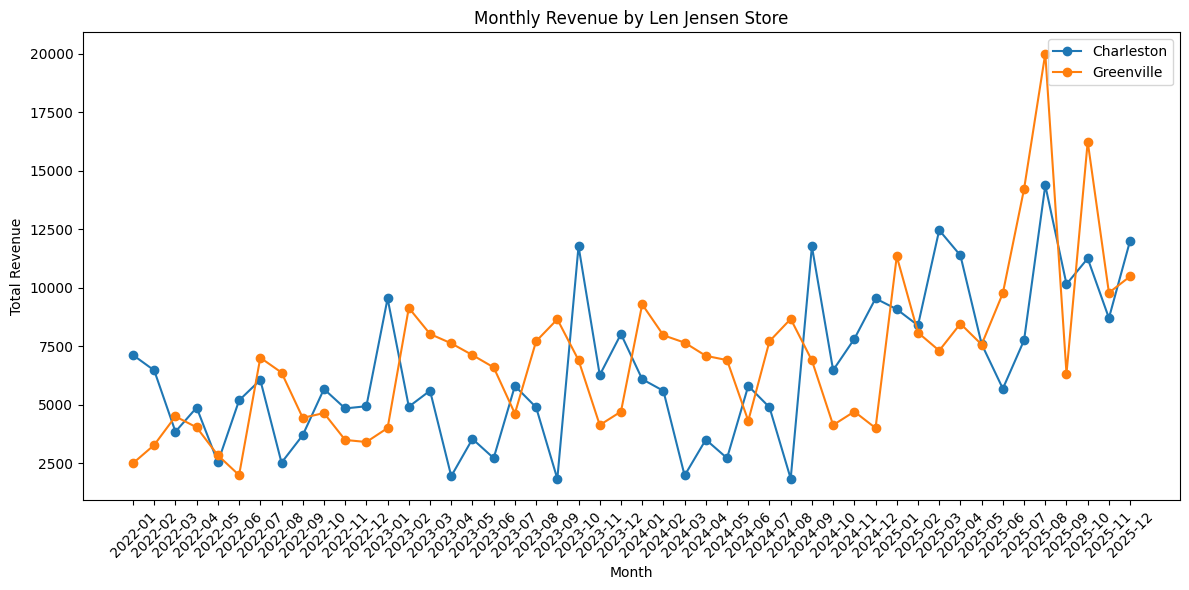

In [15]:
plt.figure(figsize=(12,6))

for store in monthly_revenue["Store Location"].unique():
    store_data = monthly_revenue[monthly_revenue["Store Location"] == store]
    plt.plot(store_data["Month"], store_data["Sale Amount"], marker="o", label=store)

plt.title("Monthly Revenue by Len Jensen Store")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# **Question 3: Rank store sales performance**

In [16]:
store_ranking = len_sales.groupby(["Store ID", "Store Location"])["Sale Amount"].sum().reset_index()
store_ranking = store_ranking.sort_values("Sale Amount", ascending=False)
store_ranking

,Store ID,Store Location,Sale Amount
1,853,Greenville,337002.00
0,852,Charleston,311810.56


chart

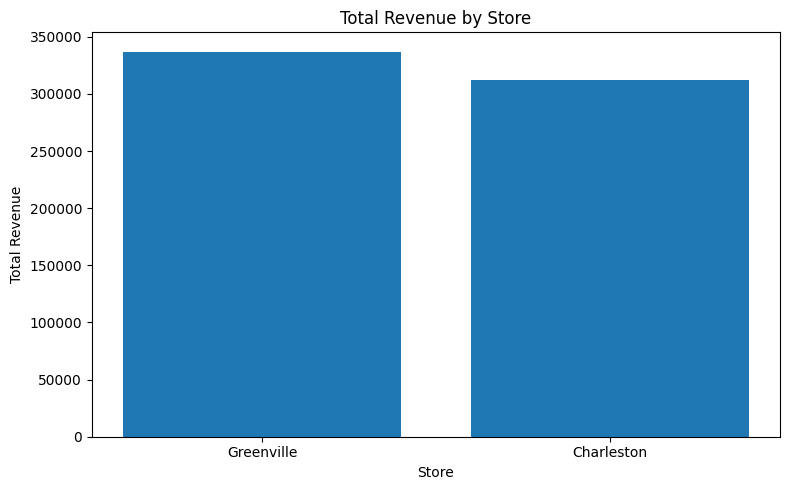

In [17]:
plt.figure(figsize=(8,5))
plt.bar(store_ranking["Store Location"], store_ranking["Sale Amount"])
plt.title("Total Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# **Question 4: Top customers**

First clean the customers column names:

In [18]:
customers.columns = customers.columns.str.strip()

Then merge customers with sales:

In [19]:
len_sales_customers = len_sales.dropna(subset=["RewardsID"]).copy()
len_sales_customers["RewardsID"] = len_sales_customers["RewardsID"].astype(int)

len_sales_customers = len_sales_customers.merge(
    customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

Top customers:

In [20]:
top_customers = len_sales_customers.groupby(
    ["Store ID", "Store Location", "RewardsID", "name"]
)["Sale Amount"].sum().reset_index()

top_customers = top_customers.sort_values("Sale Amount", ascending=False)
top_customers.head(10)

,Store ID,Store Location,RewardsID,name,Sale Amount
292,853,Greenville,340,Jin Kwon,1786.05
143,852,Charleston,404,Roman Roy,1778.84
82,852,Charleston,213,Jazz,1763.70
203,853,Greenville,74,Ben Chang,1514.20
86,852,Charleston,227,Debra Morgan,1388.56
269,853,Greenville,243,Dayanara Diaz,1359.30
31,852,Charleston,72,Pierce H.,1317.70
199,853,Greenville,48,Andy B.,1301.88
276,853,Greenville,280,Cal Abar,1294.30
334,853,Greenville,457,Skyler White,1294.30


chart


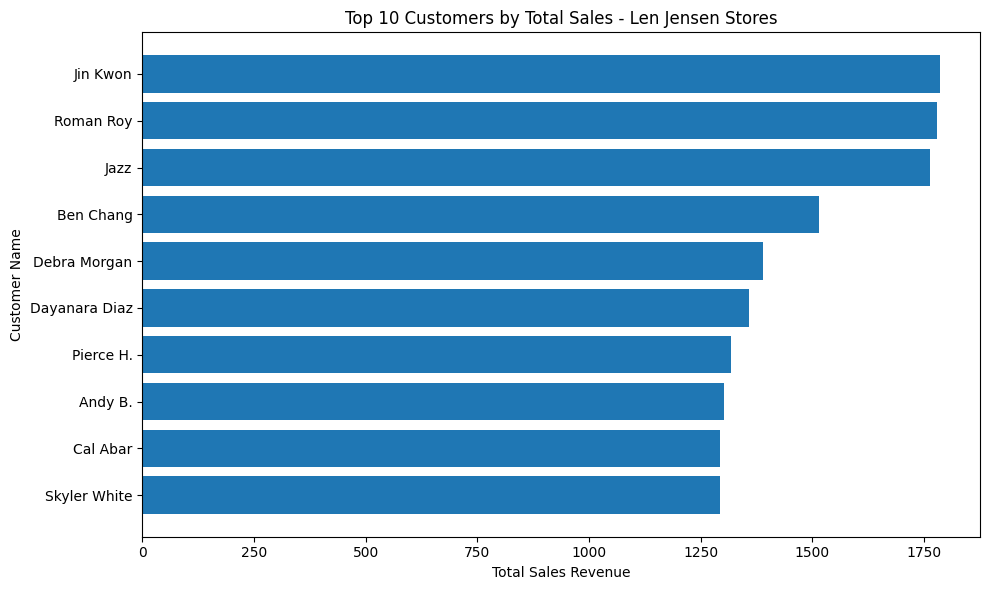

In [21]:
top_10_customers = top_customers.head(10).copy()
top_10_customers["name"] = top_10_customers["name"].fillna("Unknown Customer")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers["name"],
    top_10_customers["Sale Amount"]
)

plt.title("Top 10 Customers by Total Sales - Len Jensen Stores")
plt.xlabel("Total Sales Revenue")
plt.ylabel("Customer Name")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Question 5: Transactions and revenue by product category**

First merge products and categories:

In [22]:
len_full = len_sales.merge(products, on="Prod Num", how="left")

len_full = len_full.merge(
    categories,
    on=["CategoryID", "SubcategoryID"],
    how="left"
)

len_full.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Month,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,853,NaN,105453-T,159.58,Greenville,South Carolina,Len Jensen,South,Andy Gisselquist,2022-01,Organizational Behavior,100,100-bus,Textbooks,Business & Economics
1,2022-01-03,852,NaN,105615-B,28.92,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist,2022-01,Harry Potter and the Sorcerers Stone,125,125-fic,Books (General),Fiction
2,2022-01-03,853,454.0,105424-T,192.26,Greenville,South Carolina,Len Jensen,South,Andy Gisselquist,2022-01,Organic Chemistry I,100,100-sci,Textbooks,Science
3,2022-01-04,852,NaN,105320-IT,30.16,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist,2022-01,Belkin BoostCharge 32W USB-C Wall Charger,120,120-cha,Technology & Accessories,Chargers and Power Adapters
4,2022-01-04,852,NaN,105655-M,61.14,Charleston,South Carolina,Len Jensen,South,Andy Gisselquist,2022-01,LTCA Year Up Embroidered Baseball Cap (Navy Blue),130,130-hat,Apparel and Merchandise,Hats and Caps


Transactions by category:

In [23]:
category_transactions = len_full.groupby(
    ["Store ID", "Store Location", "Category"]
).size().reset_index(name="Transaction Count")

category_transactions.sort_values("Transaction Count", ascending=False)

,Store ID,Store Location,Category,Transaction Count
10,853,Greenville,Technology & Accessories,517
9,853,Greenville,Stationery and Supplies,464
6,853,Greenville,Apparel and Merchandise,460
4,852,Charleston,Technology & Accessories,460
7,853,Greenville,Art Supplies,450
0,852,Charleston,Apparel and Merchandise,447
3,852,Charleston,Stationery and Supplies,442
1,852,Charleston,Art Supplies,440
5,852,Charleston,Textbooks,295
11,853,Greenville,Textbooks,293


Revenue by category:

In [24]:
category_revenue = len_full.groupby(
    ["Store ID", "Store Location", "Category"]
)["Sale Amount"].sum().reset_index()

category_revenue.sort_values("Sale Amount", ascending=False)

,Store ID,Store Location,Category,Sale Amount
10,853,Greenville,Technology & Accessories,248310.49
4,852,Charleston,Technology & Accessories,223807.85
5,852,Charleston,Textbooks,52045.74
11,853,Greenville,Textbooks,51193.25
6,853,Greenville,Apparel and Merchandise,15736.48
0,852,Charleston,Apparel and Merchandise,14678.24
1,852,Charleston,Art Supplies,14115.45
7,853,Greenville,Art Supplies,13888.04
2,852,Charleston,Books (General),4945.00
8,853,Greenville,Books (General),4864.53


chart


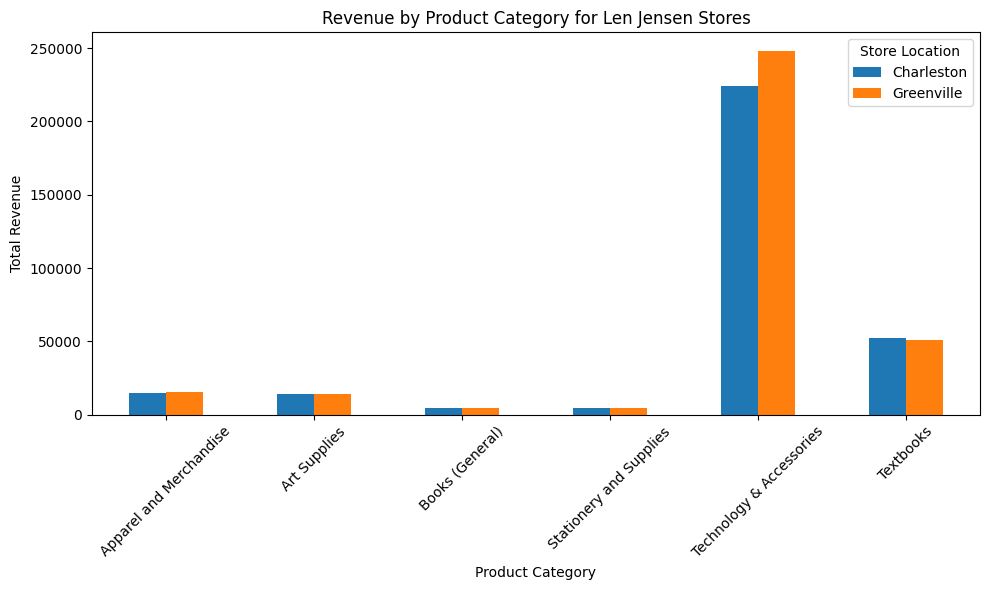

In [26]:
category_revenue_pivot = category_revenue.pivot(
    index="Category",
    columns="Store Location",
    values="Sale Amount"
)

category_revenue_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Revenue by Product Category for Len Jensen Stores")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Question 6: Monthly transactions and revenue by product category**

This section shows category performance over time. It helps identify which product categories are popular each month and where marketing may have room to grow.

In [27]:
category_monthly = len_full.groupby(
    ["Month", "Store Location", "Category"]
).agg(
    Transaction_Count=("Sale Amount", "count"),
    Total_Revenue=("Sale Amount", "sum")
).reset_index()

category_monthly.head(10)

,Month,Store Location,Category,Transaction_Count,Total_Revenue
0,2022-01,Charleston,Apparel and Merchandise,7,165.90
1,2022-01,Charleston,Art Supplies,2,136.33
2,2022-01,Charleston,Books (General),2,52.36
3,2022-01,Charleston,Stationery and Supplies,3,26.57
4,2022-01,Charleston,Technology & Accessories,10,6103.91
5,2022-01,Charleston,Textbooks,4,644.51
6,2022-01,Greenville,Apparel and Merchandise,5,91.30
7,2022-01,Greenville,Art Supplies,6,233.50
8,2022-01,Greenville,Books (General),2,43.80
9,2022-01,Greenville,Stationery and Supplies,4,34.52


### Monthly Category Revenue Chart

This chart shows monthly sales revenue by category for Len Jensen’s stores. It helps compare category trends over the full time period.

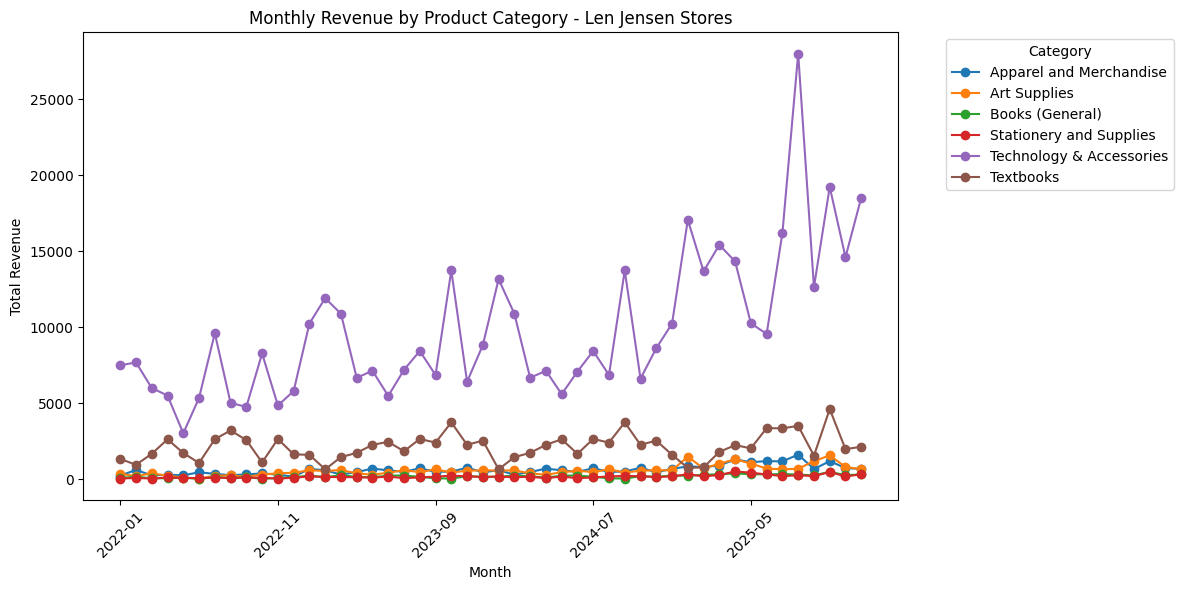

In [28]:
monthly_category_revenue = category_monthly.groupby(
    ["Month", "Category"]
)["Total_Revenue"].sum().reset_index()

monthly_category_pivot = monthly_category_revenue.pivot(
    index="Month",
    columns="Category",
    values="Total_Revenue"
)

monthly_category_pivot.plot(kind="line", figsize=(12, 6), marker="o")

plt.title("Monthly Revenue by Product Category - Len Jensen Stores")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **Final Recommendation**

Based on the analysis, I recommend focusing next quarter’s marketing attention on **Greenville Store 853** while still supporting Charleston Store 852 with targeted promotions.

Greenville is the top-performing Len Jensen store, with **$337,002.00** in total revenue compared with **$311,810.56** for Charleston. The strongest category in both stores is **Technology & Accessories**, generating **$248,310.49** in Greenville and **$223,807.85** in Charleston.

My recommendation is to run a South region back-to-school **Technology & Accessories** campaign focused on items like tablets, calculators, software, and accessories. To grow smaller categories, the campaign should include bundle promotions that connect technology purchases with **Stationery and Supplies**, **Art Supplies**, and **Books**. This strategy supports the strongest revenue driver while also creating growth opportunities for lower-performing categories.